## Requirements.txt
langgraph
langchain
langchain-core
langchain-aws
boto3

In [ ]:
# Import libraries needed for state management, LangGraph workflow, prompt building,
# and LLM interaction with Bedrock.
from typing import Annotated, TypedDict
import operator
from langgraph.graph import StateGraph, START, END

from langchain_core.prompts import ChatPromptTemplate
from langchain_aws import ChatBedrockConverse

In [ ]:
# Create the LLM client that will decide which tool to use for the user's question.
# This model is hosted through AWS Bedrock in the specified region.
llm = ChatBedrockConverse(
    model="anthropic.claude-3-5-sonnet-20241022-v2:0",
    region_name="us-east-1",
    temperature=0.1,
    max_tokens=300
)

In [ ]:
# Define the tools available to the agent.
# Each tool simulates a real external system and returns a result for the given query.
def web_search(query: str) -> str:
    return f"Web Search Result: {query}"

def pubmed_search(query: str) -> str:
    return f"PubMed Result: {query}"

In [ ]:
# Define the agent state structure.
# This holds the user question, selected tool, answer, and conversation history.
class AgentState(TypedDict):
    question:str
    tool: str
    answer: str
    history: Annotated[list[dict], operator.add]  

In [ ]:
# Build a prompt that tells the LLM to choose only between the two tools.
# It acts like a router: "pubmed" for medical content and "web" for general content.
tool_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an intelligent healthcare routing agent.
Available Tools:
1. pubmed — disease, treatment, medicine, drug, diagnosis
2. web    — weather, news, sports, general information
Reply ONLY with: pubmed OR web"""),
    ("human", "{question}"),
])

In [ ]:
# Allowed tool names for validation after the model makes a choice.
VALID_TOOLS = {"pubmed", "web"}

In [ ]:
# Decide which tool should be used for the current question.
# The LLM chooses between pubmed and web, and we validate the result.
def decide_tool(state: AgentState) -> dict:
    question = state.get("question", "")
    chain = tool_prompt | llm
    tool = chain.invoke({"question": question}).content.strip().lower()
    tool = tool if tool in VALID_TOOLS else "web"
    print(f"\nLLM Selected Tool: {tool}")

    return {"tool": tool}

In [ ]:
# Run the chosen tool and store the result in the state.
# This node simulates the actual tool execution and records the interaction in history.
def execute_tool(state:AgentState)-> dict:
    question = state.get("question", "")
    tool = state.get("tool", "web")
    result = pubmed_search(question) if tool == "pubmed" else web_search(question)

    return {
        "answer": result,
        "history": [{"question": question, "tool": tool, "answer": result}],  # appended via reducer

    }

In [ ]:
# Build the graph workflow:
# START -> decide_tool -> execute_tool -> END
# This defines the sequential execution flow of the agent.
builder = StateGraph(AgentState)

builder.add_node("decide_tool", decide_tool)
builder.add_node("execute_tool", execute_tool)

builder.add_edge(START, "decide_tool")
builder.add_edge("decide_tool", "execute_tool")

builder.add_edge("execute_tool", END)
graph = builder.compile()


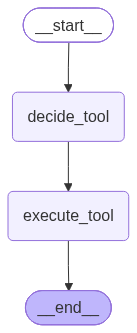

In [40]:
# Display the compiled LangGraph workflow for quick inspection.
graph

In [ ]:
# Invoke the agent with a sample question to test the full workflow.
result = graph.invoke({
    "question": "What is the treatment for diabetes?",
    "tool": "",
    "answer": "",
    "history": [],
})

In [ ]:
# Print the final answer returned by the tool and the interaction history.
print(f"\nFinal Answer:\n{result['answer']}")
print(f"\nHistory:\n{result['history']}")